In [1]:
import numpy as np
import hyperspy.api as hs
from tifffile import imread

In [2]:
import matplotlib.pyplot as plt
import colorcet
import stem_analysis.plot as saplt
from matplotlib_scalebar.scalebar import ScaleBar
from skimage.transform import resize
from skimage.filters import difference_of_gaussians

In [3]:
from tqdm import tqdm, trange

In [4]:
%matplotlib widget

In [5]:
from scipy.interpolate import RBFInterpolator

In [6]:
from skimage.feature import match_template, peak_local_max
from skimage.filters import window
from scipy.ndimage import median_filter, rotate, gaussian_filter
from skimage.feature import match_template

In [7]:
import os

In [8]:
#plt.style.use("/Users/nihy/Desktop/stem_analysis/src/stem_analysis/nature.mplstyle")

In [9]:
def median_absolute_deviation(data):
    """
    Calculates the Mean Absolute Deviation (MAD) of a dataset using numpy.
    
    Args:
        data (list or np.array): The input dataset.
        
    Returns:
        float: The mean absolute deviation.
    """
    median = np.median(data)
    absolute_deviations = np.abs(data - median)
    mad = np.median(absolute_deviations)
    return mad

In [10]:
def Karen(dp, window_size):
    """
    Applies the Karen algorithm to an image to enhance features and reduce noise.
    
    Args:
        dp (np.array): The input image data as a 2D numpy array.
        window_size (int): The size of the window for local processing.
        pad_mode (str): The mode for padding the image borders (default is "edge").
        
    Returns:
        np.array: The processed image after applying the Karen algorithm.
    """
    dp_out = dp.copy()

    med = median_filter(dp_out, size=window_size, mode="nearest")
    mad = median_filter(np.abs(dp_out - med), size=window_size, mode="nearest")

    asigma = np.abs(mad*3*1.4826)
    mask = np.logical_or(dp_out < (med - asigma), dp_out > (med + asigma))
    dp_out[mask] = (med+2.2*mad)[mask]
            
    return dp_out

In [11]:
work_dir = '/Users/nihy/Desktop/Working Data/Lu166/ADF STEM/053'

In [12]:
dp_path = '/Users/nihy/Desktop/Working Data/Lu166/ADF STEM/053/raw_image.tif'
dp = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(imread(dp_path))))

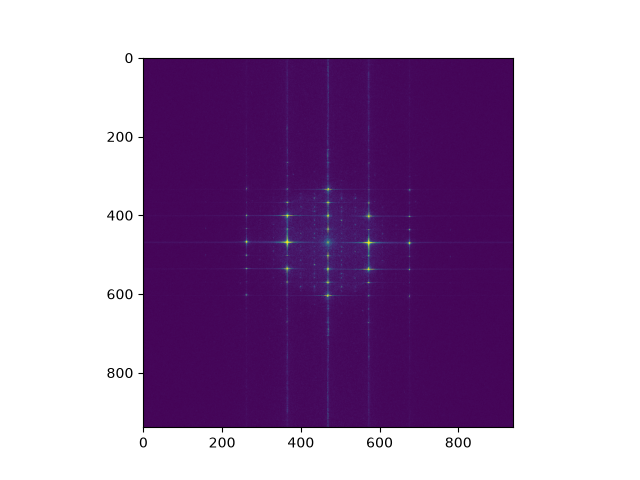

In [13]:
plt.figure()
plt.imshow(np.abs(dp), vmax = 1000)

In [14]:
#dp1_path = '/Users/nihy/Desktop/Working Data/Lu166/NBD 4DSTEM/20 K/NBD_SP1_avg_SI.tif'
#dp2_path = '/Users/nihy/Desktop/Working Data/Lu166/NBD 4DSTEM/20 K/NBD_SP2_avg_SI.tif'
#dp1 = imread(dp1_path)
#dp2 = imread(dp2_path)

In [15]:
dq = dk = 0.14013 # in nm^-1

# Center the diffraction pattern

In [16]:
#dp_centered = gaussian_filter(dp, 0.5)#.data[265-230:265+230, 278- 230: 278+230]
#dp_centered = dp1

# Find Bragg Reflections

In [28]:
#peaks1 = peak_local_max(dp1, min_distance = 4, threshold_rel = 0.009, exclude_border = True)
#peaks2 = peak_local_max(dp2, min_distance = 4, threshold_rel = 0.009, exclude_border = True)

peaks = peak_local_max(np.abs(dp), min_distance = 4, threshold_rel = 0.004, exclude_border = True)

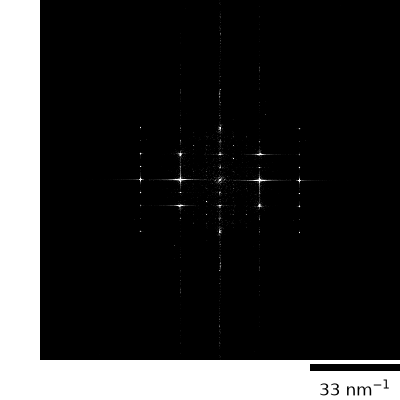

/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_84087/1885957181.py:3: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  fig_ax.scatter(peaks[:, 1], peaks[:, 0], s = 10, c = 'b', marker = 'o', facecolors = 'none', linewidths = 2)


In [29]:
fig = plt.figure(figsize = (4, 4))
fig_ax = saplt.PlotImage(fig, np.abs(dp), dq, dimension = 'reciprocal-space' ,vmax =  1000, vmin = 100)
fig_ax.scatter(peaks[:, 1], peaks[:, 0], s = 10, c = 'b', marker = 'o', facecolors = 'none', linewidths = 2)

# Refine DP position By Gaussian_fitting

In [30]:
from scipy.optimize import curve_fit

In [31]:
def gaussian2d(coords, amp, x0, y0, sx, sy, theta, offset):
    """Rotated 2D Gaussian, flattened for curve_fit."""
    x, y = coords
    ct, st = np.cos(theta), np.sin(theta)

    xr =  (x - x0) * ct + (y - y0) * st
    yr = -(x - x0) * st + (y - y0) * ct

    g = offset + amp * np.exp(-0.5 * ((xr / sx) ** 2 + (yr / sy) ** 2))
    return g.ravel()

In [32]:
def fit_gaussian2d(img, p0=None, bounds=None):
    """
    Fit a 2D Gaussian to a single 2D image patch.
    Returns (params, covariance, fitted_image).
    params = [amp, x0, y0, sx, sy, theta, offset]
    """
    img = np.asarray(img, dtype=float)
    ny, nx = img.shape
    X, Y = np.meshgrid(np.arange(nx), np.arange(ny))

    if p0 is None:
        offset0 = np.median(img)
        amp0 = max(img.max() - offset0, 1e-6)
        y0, x0 = np.unravel_index(np.argmax(img), img.shape)
        sx0 = max(nx / 6.0, 1.0)
        sy0 = max(ny / 6.0, 1.0)
        theta0 = 0.0
        p0 = [amp0, x0, y0, sx0, sy0, theta0, offset0]

    if bounds is None:
        lower = [0.0,       0.0,       0.0,       0.3, 0.3, -np.pi/2, -np.inf]
        upper = [np.inf, nx - 1.0, ny - 1.0,   nx,   ny,   np.pi/2,  np.inf]
        bounds = (lower, upper)

    popt, pcov = curve_fit(
        gaussian2d,
        (X, Y),
        img.ravel(),
        p0=p0,
        bounds=bounds,
        maxfev=200
    )
    fit_img = gaussian2d((X, Y), *popt).reshape(ny, nx)
    return popt, pcov, fit_img

In [33]:
peaks_fit = []
for p in peaks:
    r, c = p
    window_size = 5

    p0 = [1e5, 4, 4, 1, 1, 0, 0]
    bounds = ([0.0, 0.0, 0.0, 0.3, 0.3, -np.pi/2, 0],
          [np.inf, 6.0, 6.0, 10.0, 10.0, np.pi/2, np.inf])

    patch = dp[r-window_size:r+window_size+1, c-window_size:c+window_size+1]
    popt, pcov, fit_img = fit_gaussian2d(patch, p0=p0, bounds=bounds)
    peaks_fit.append((popt))


/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_84087/1666051373.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  img = np.asarray(img, dtype=float)


RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [22]:
peaks2_fit = []
for p in peaks2:
    r, c = p
    window_size = 5

    p0 = [1e5, 4, 4, 1, 1, 0, 0]
    bounds = ([0.0, 0.0, 0.0, 0.3, 0.3, -np.pi/2, 0],
          [np.inf, 6.0, 6.0, 10.0, 10.0, np.pi/2, np.inf])

    patch = dp2[r-window_size:r+window_size+1, c-window_size:c+window_size+1]
    popt, pcov, fit_img = fit_gaussian2d(patch, p0=p0, bounds=bounds)
    peaks2_fit.append((popt))


In [23]:
peaks1_fit = np.array(peaks1_fit)
peaks1_pos_fit = peaks1 + peaks1_fit[...,1:3]-5

In [24]:
peaks2_fit = np.array(peaks2_fit)
peaks2_pos_fit = peaks2 + peaks2_fit[...,1:3]-5

# Punch and Fill to remove Bragg Reflections

In [34]:
def PunchAndFill(dp, peaks, radius, interpolate = True):
    rr, cc = np.mgrid[0:dp.shape[0], 0:dp.shape[1]]
    punched = dp.copy().astype(np.float64)
    for peak in peaks:
        mask = (rr - peak[0])**2 + (cc - peak[1])**2 < radius**2
        punched[mask] = np.nan

    target_coords = np.column_stack((rr.ravel(), cc.ravel()))
    valid_mask = ~np.isnan(punched)
    coords = np.column_stack((rr[valid_mask], cc[valid_mask]))
    values = punched[valid_mask]

    missing_mask = ~valid_mask
    missing_coords = np.column_stack((rr[missing_mask], cc[missing_mask]))
    if interpolate:
        rbf = RBFInterpolator(
            coords,
            values,
            kernel='multiquadric',
            epsilon=4.5,
            smoothing=2.5,
            neighbors=50
        )

        punched_rbf = punched.copy()
        punched_rbf[missing_mask] = rbf(missing_coords)
        
        return punched_rbf
    else:
        punched = np.nan_to_num(punched, copy=False, nan = 1200)
        return punched
    

    

In [41]:
punched_real = PunchAndFill(dp.real, peaks, 15, interpolate= True)
punched_imag = PunchAndFill(dp.imag, peaks,15, interpolate= True)
punched_complex = punched_real + 1j * punched_imag
#punched2 = PunchAndFill(dp2, peaks2_pos_fit, 5, interpolate= True)

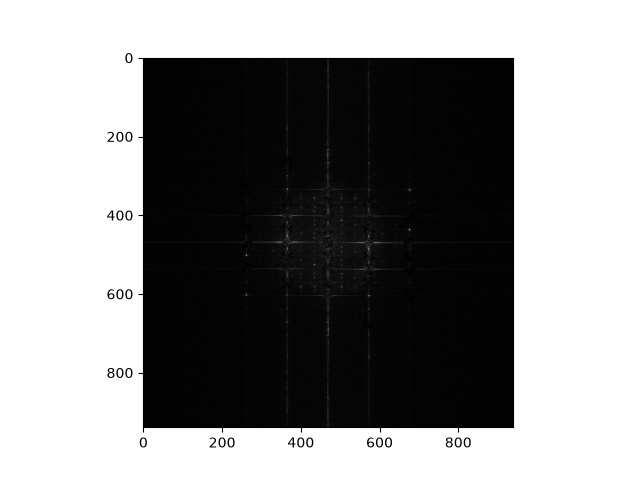

In [42]:
plt.figure()
plt.imshow(np.abs(punched_complex), cmap='gray' ,vmax = 1000)

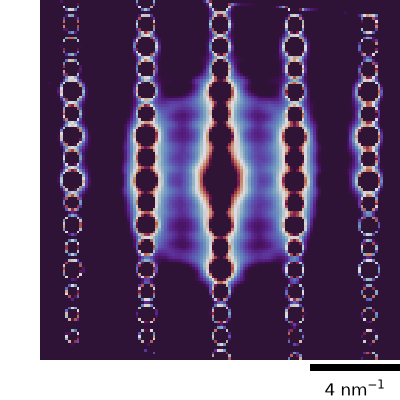

In [34]:
fig = plt.figure(figsize = (4, 4))
fig_ax = saplt.PlotImage(fig, punched,
                dq,
                cmap = 'twilight_shifted',
                interpolation = 'nearest',
                vmin = 1.2e3, 
                vmax = 3e3, 
                norm = 'log',
                dimension = 'reciprocal-space')
fig_ax.scatter(peaks[:, 1], peaks[:, 0], c='w', marker = 'o', s = 50, rasterized = True)
#fig_ax.set_xlim(30, punched.shape[1]-30)
#fig_ax.set_ylim(30, punched.shape[0]-30)
plt.savefig(os.path.join(work_dir, 'panbd_punched.svg'), transparent = True, pad_inches = 0, bbox_inches = 'tight', dpi = 300)

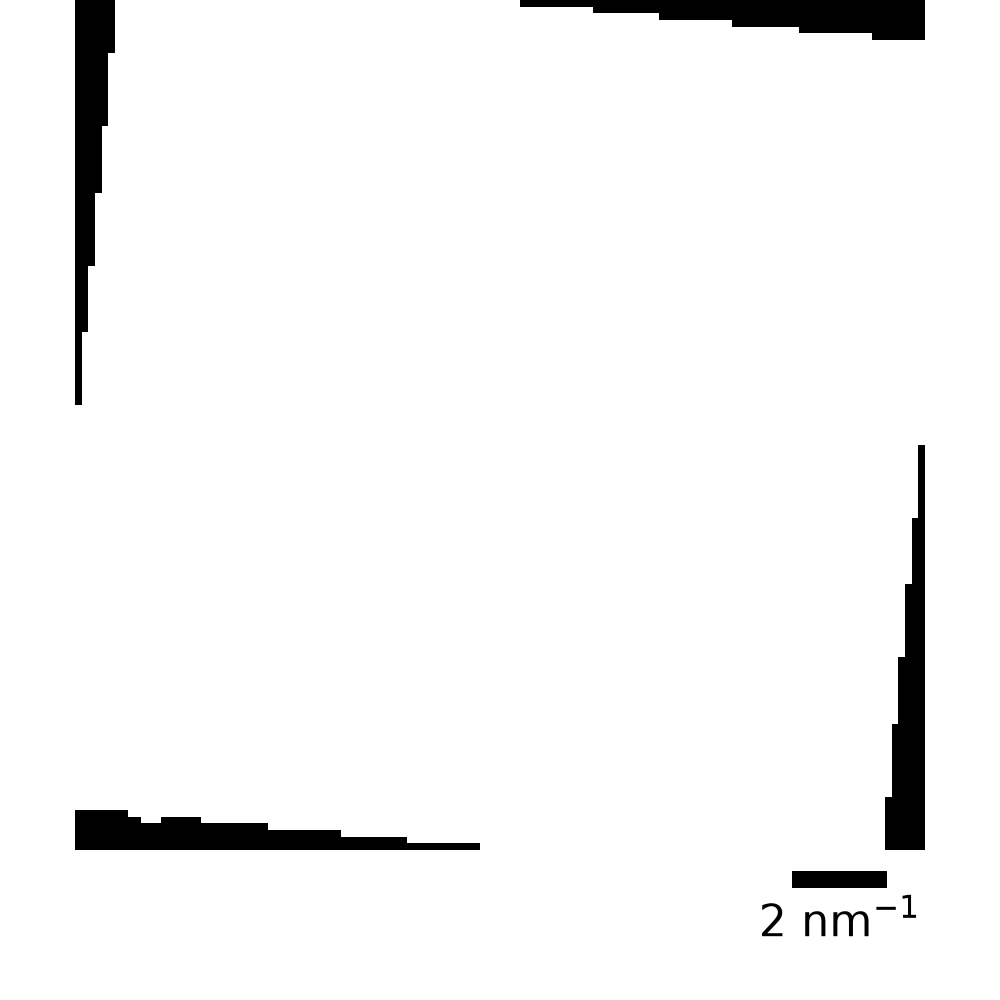

In [114]:
fig = plt.figure(figsize = (10, 10))
saplt.PlotDiff(fig, punched, dq, cmap = 'gray', vmin = 1e-9, vmax = 1e-5)

In [43]:
w = window('hann', punched_complex.shape)

In [49]:
dp_diffuse_pad = np.pad(punched_complex*w, 
                        0, 
                      mode='constant')

In [56]:
dpdf = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(dp_diffuse_pad)))

In [57]:
dr = 1/(dq*dp_diffuse_pad.shape[0])

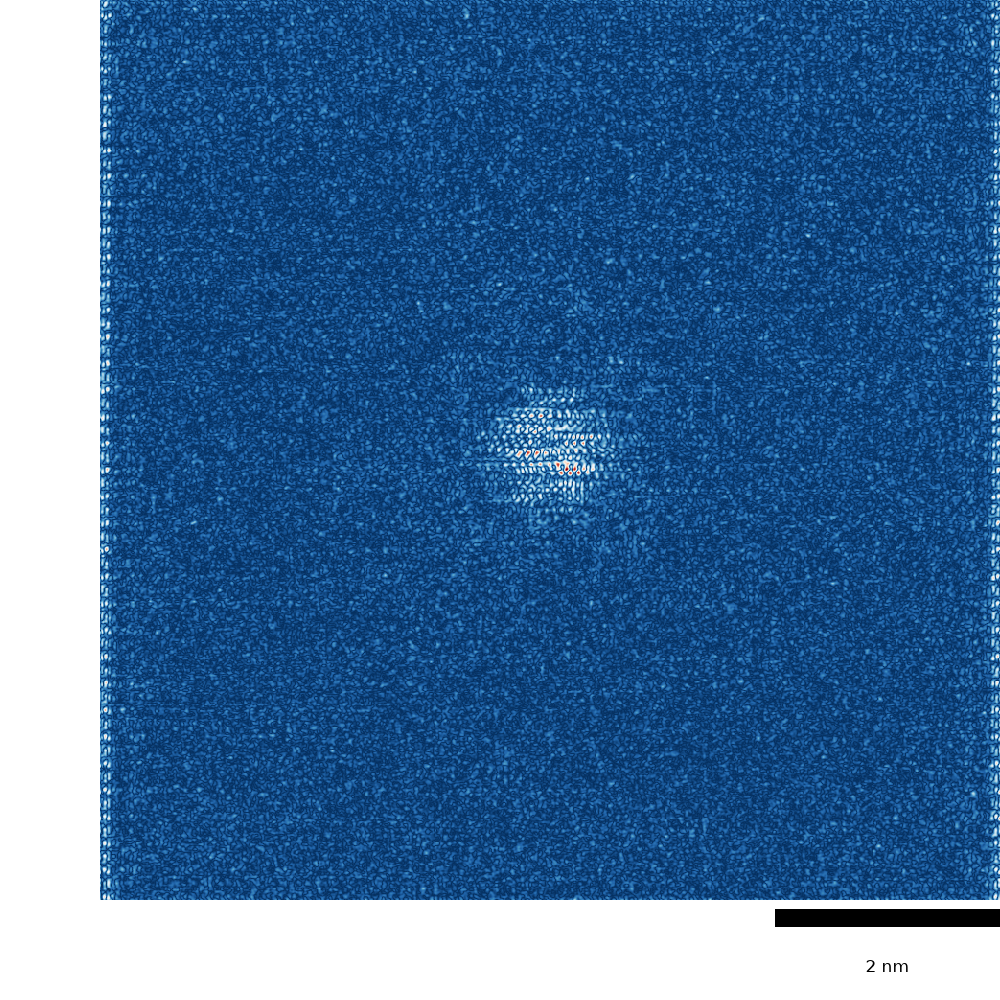

<Axes: >

In [59]:
fig = plt.figure(figsize = (10, 10))
fig.subplots_adjust(0, 0, 1, 1)
saplt.PlotImage(fig, np.abs(dpdf), dr, cmap = 'RdBu_r')

# Plotting

In [27]:
delta_pdf_rot = rotate(dpdf.real, 16.5-90, reshape = False)[punched.shape[0] - 230: punched.shape[0] + 230, 
                                                            punched.shape[1] - 230: punched.shape[1] + 230]

#delta_pdf_rot = dpdf.real

In [28]:
def PlotDeltaPDF(fig, delta_pdf_rot, dr, cmap = 'RdBu_r', vmin = None, vmax = None, plot_lattice = False, lattice_dist = None, lattice_range = None):
    ax = fig.add_subplot(111)

    if vmin == None:
        vmin = delta_pdf_rot.min()
    if vmax == None:
        vmax = delta_pdf_rot.max()

    ax.imshow(delta_pdf_rot, cmap=cmap, vmin=vmin, vmax=vmax)

    scalebar = ScaleBar(dr, 
                                    "nm",
                                    dimension = "si-length",
                                    location = 'lower right',
                                    frameon = False,
                                    length_fraction = 0.25,    
                                    height_fraction = 0.02,
                                    bbox_to_anchor=(1, -0.12),
                                    bbox_transform =ax.transAxes,
                                    font_properties = {'size': 32},)
    ax.add_artist(scalebar)

    return ax

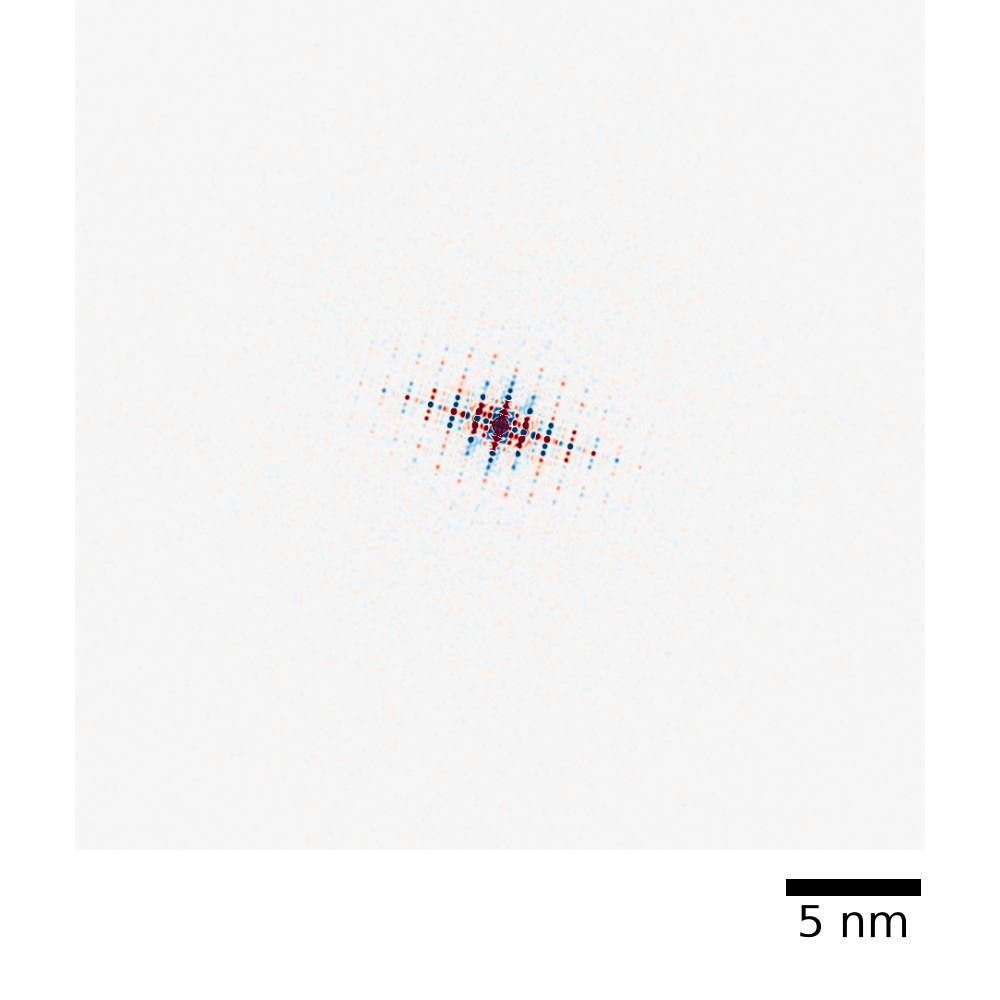

In [29]:
fig = plt.figure(figsize = (10, 10))
fig.subplots_adjust(0, 0, 1, 1)
saplt.PlotImage(fig, dpdf.real, dr, cmap = 'RdBu_r', vmin = -1e8, vmax = 1e8)

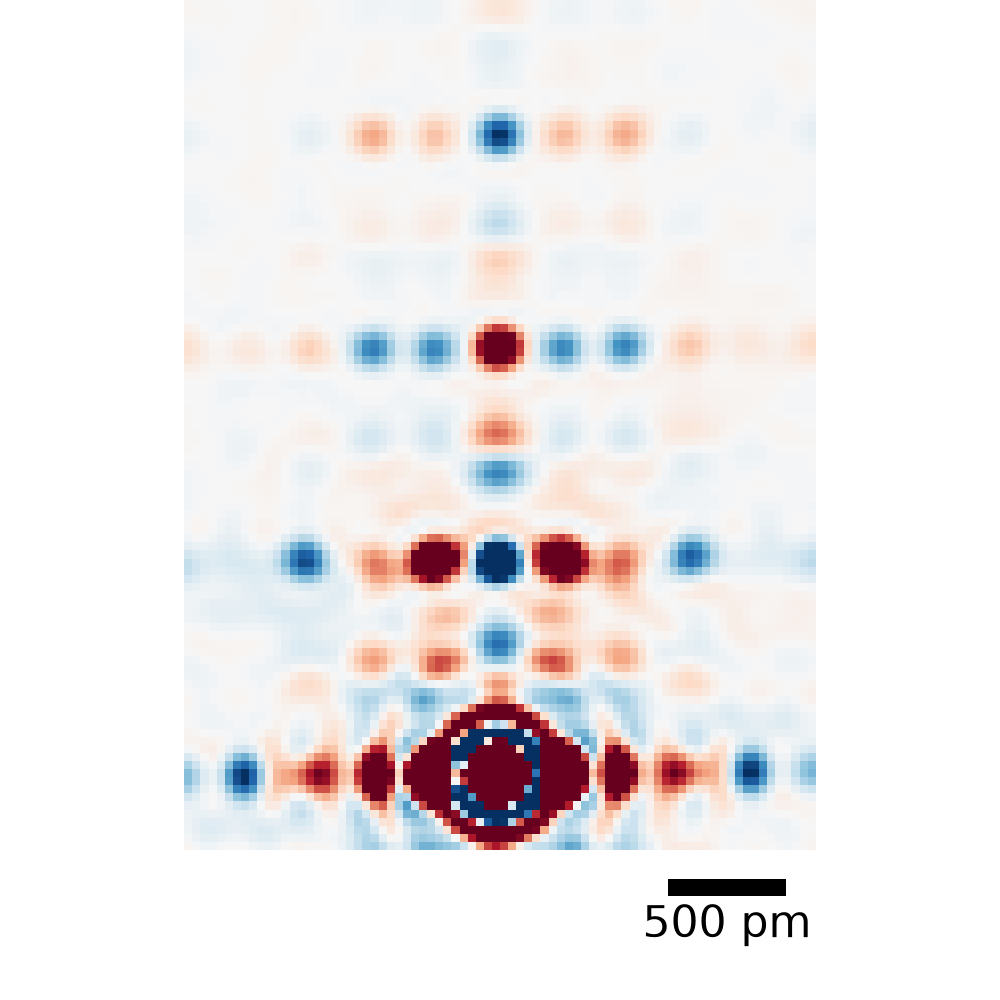

In [ ]:
fig = plt.figure(figsize = (10, 10))
saplt.PlotImage(fig, delta_pdf_rot[delta_pdf_rot.shape[0]//2 - 95 : delta_pdf_rot.shape[0]//2 + 10, 
                                   delta_pdf_rot.shape[1]//2 - 39 : delta_pdf_rot.shape[1]//2 + 39], dr, cmap ='RdBu_r',vmax = 3e8, vmin = -3e8)
ax = plt.gca()
ax.axis("on")
ax.grid(visible = True, color = 'k', alpha = 0.5, linewidth = 2)

ax.set_yticks(np.arange(0, 7)[::-1]*26.5/2+16., [0, 0.5, 1, 1.5, 2, 2.5, 3], fontsize = 24)
ax.set_xticks(np.arange(-4, 5, 2)*7.8 + 38.5, [-4, -2, 0, 2, 4], fontsize = 24)

for tick in ax.xaxis.get_major_ticks() + ax.yaxis.get_major_ticks():
    tick.tick1line.set_rasterized(True)
    tick.tick2line.set_rasterized(True)

for gridline in ax.get_xgridlines() + ax.get_ygridlines():
    gridline.set_rasterized(True)

for spine in ax.spines.values():
    spine.set_rasterized(True)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_rasterized(True)


#plt.savefig(os.path.join(work_dir, "Delta_PDF_cropped_labelled_rasterized.svg"), dpi = 300, transparent = True, pad_inches = 0)